<a href="https://colab.research.google.com/github/gergielias-max/Deep-learning/blob/main/Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv('/var/local/Measurement_summary.csv')

print(df.head())
print(df.columns)

   Measurement date  Station code  \
0  2017-01-01 00:00           101   
1  2017-01-01 01:00           101   
2  2017-01-01 02:00           101   
3  2017-01-01 03:00           101   
4  2017-01-01 04:00           101   

                                             Address   Latitude   Longitude  \
0  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   
1  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   
2  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   
3  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   
4  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   

     SO2    NO2     O3   CO  PM10  PM2.5  
0  0.004  0.059  0.002  1.2  73.0   57.0  
1  0.004  0.058  0.002  1.2  71.0   59.0  
2  0.004  0.056  0.002  1.2  70.0   59.0  
3  0.004  0.056  0.002  1.2  70.0   58.0  
4  0.003  0.051  0.002  1.2  69.0   61.0  
Index(['Measurement date', 'Station code', '

In [8]:
df = df.dropna()

# convert date
df['Measurement date'] = pd.to_datetime(df['Measurement date'])

# feature engineering
df['hour'] = df['Measurement date'].dt.hour
df['month'] = df['Measurement date'].dt.month

In [9]:
features = ['PM10', 'NO2', 'CO', 'SO2', 'hour', 'month']
target = 'PM2.5'

X = df[features]
y = df[target]

In [10]:
# remove extreme values
df = df[df['PM2.5'] < 300]

X = df[features]
y = df[target]

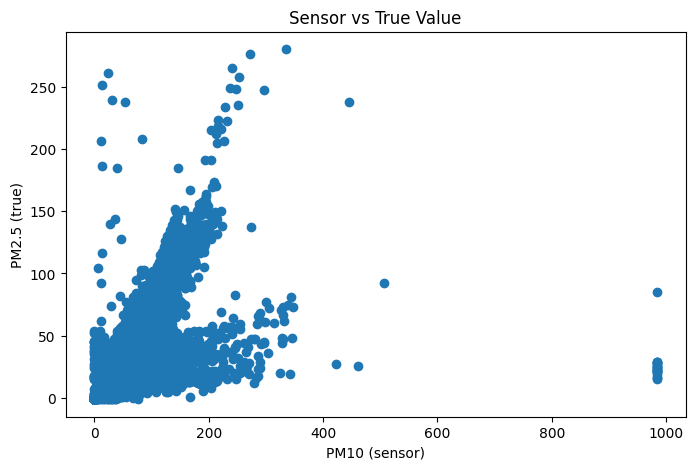

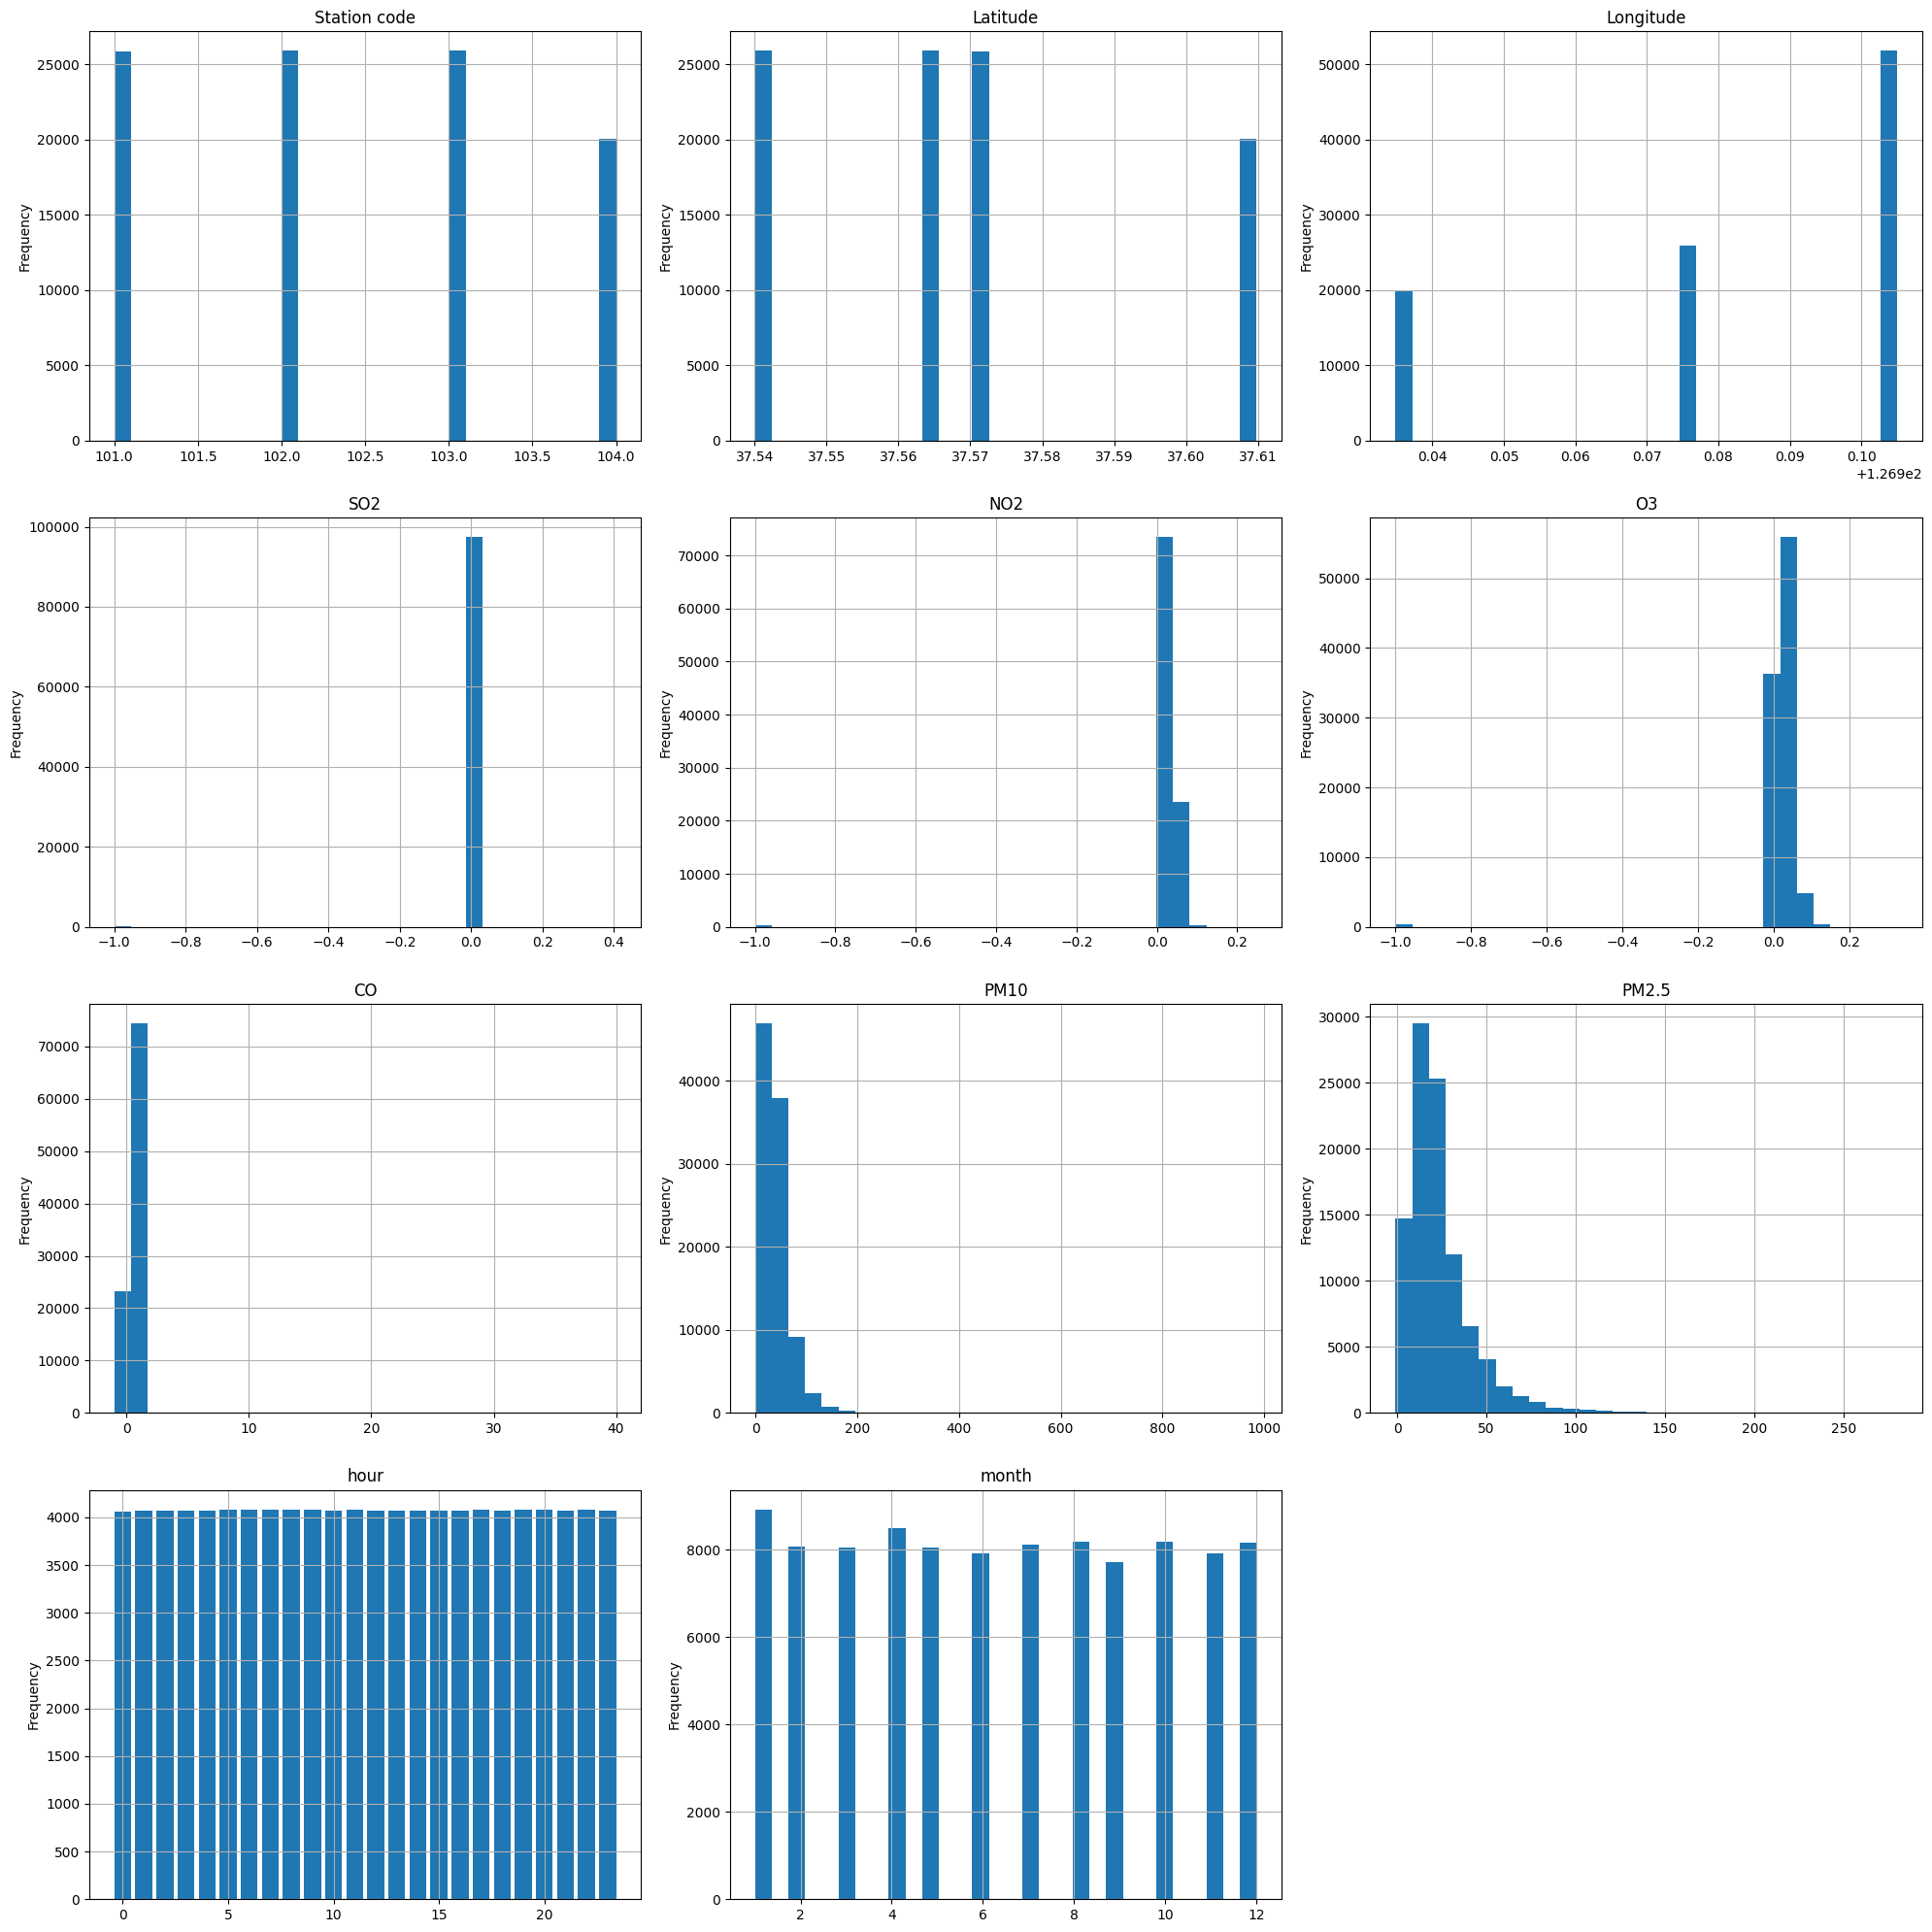

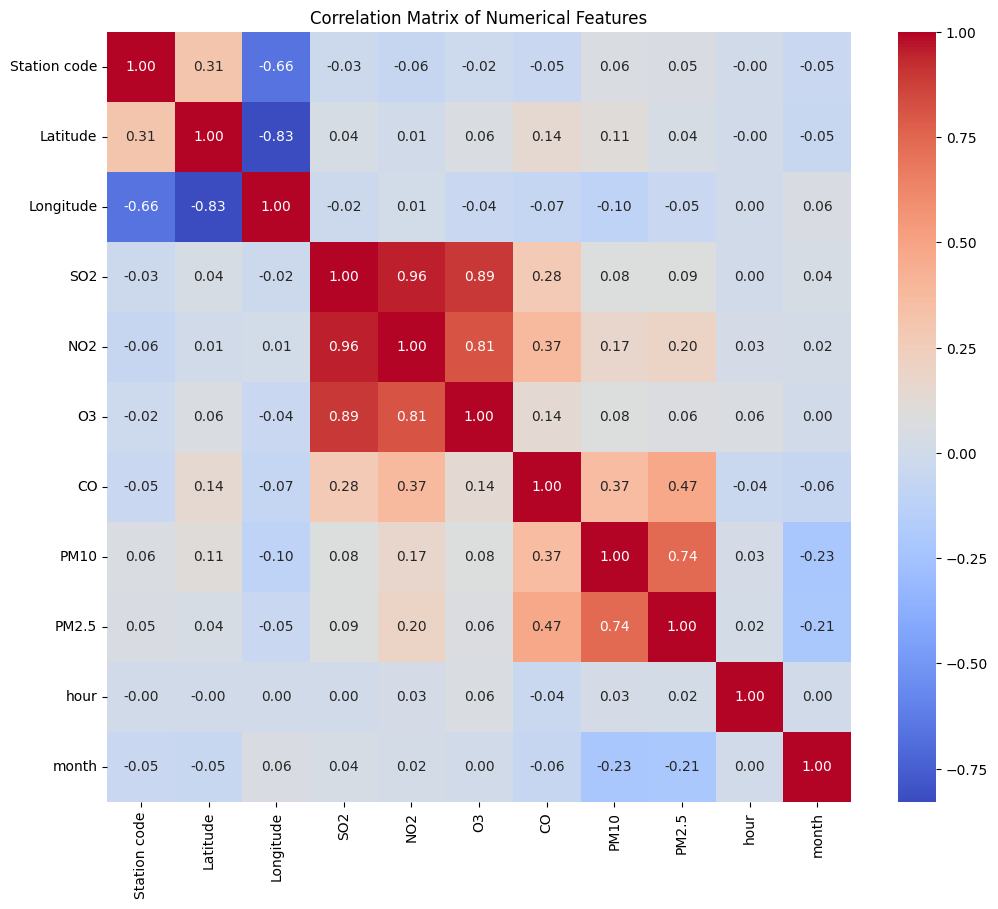

In [37]:
# scatter (viktig!)
plt.figure(figsize=(8, 5))
plt.scatter(X['PM10'], y)
plt.xlabel('PM10 (sensor)')
plt.ylabel('PM2.5 (true)')
plt.title('Sensor vs True Value')
plt.show()

# histogram (bara numeriska)
numeric_df = df.select_dtypes(include=['number'])

# Determine number of rows and columns for subplots
num_cols = len(numeric_df.columns)
num_rows = (num_cols + 2) // 3 # Roughly 3 columns per row

fig, axes = plt.subplots(num_rows, 3, figsize=(20, 5 * num_rows)) # Adjust figsize dynamically

# Flatten axes array for easy iteration if it's 2D
axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    if col == 'hour':
        # Special handling for 'hour' to ensure clear discrete bins
        bins = np.arange(numeric_df[col].min(), numeric_df[col].max() + 2) - 0.5
        numeric_df[col].hist(ax=axes[i], bins=bins, rwidth=0.8)
    else:
        numeric_df[col].hist(ax=axes[i], bins=30)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

# correlation
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [30]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [31]:
def evaluate(y_true, y_pred, name):
    print(f"--- {name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

--- Linear Regression ---
MAE: 6.579213093028374
RMSE: 12.299935782595558
R2: 0.5550609407812506

--- Random Forest ---
MAE: 4.236002628247602
RMSE: 6.667754088251035
R2: 0.8692462982795918



In [32]:
rf2 = RandomForestRegressor(n_estimators=300, max_depth=15)
rf2.fit(X_train, y_train)

y_pred_rf2 = rf2.predict(X_test)

evaluate(y_test, y_pred_rf2, "Improved Random Forest")

--- Improved Random Forest ---
MAE: 4.181843274011783
RMSE: 6.617190273864225
R2: 0.8712218773316673



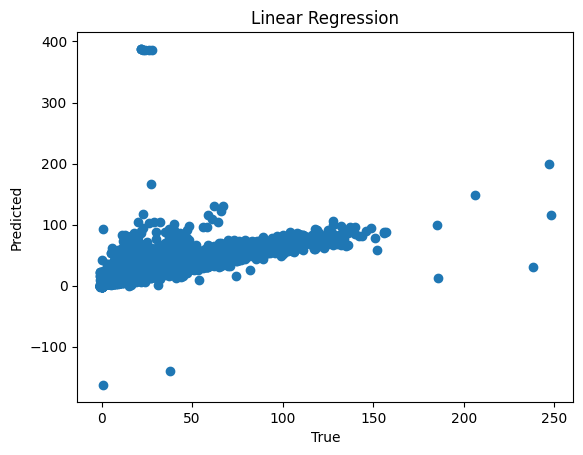

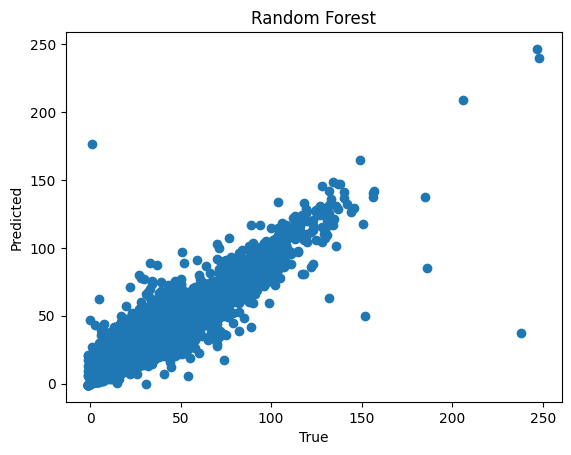

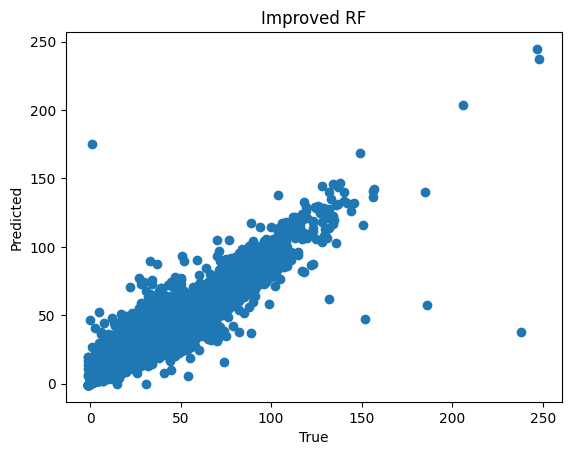

In [33]:
# Linear
plt.scatter(y_test, y_pred_lr)
plt.title("Linear Regression")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

# RF
plt.scatter(y_test, y_pred_rf)
plt.title("Random Forest")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

# Improved RF
plt.scatter(y_test, y_pred_rf2)
plt.title("Improved RF")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [34]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Improved RF'],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_rf2)
    ]
})

print(results)

               Model        R2
0  Linear Regression  0.555061
1      Random Forest  0.869246
2        Improved RF  0.871222
